# Parte IV. Monitoreo de deriva de datos con Evidently

**Predicción de falla cardíaca con *pipelines* de aprendizaje automático** · Etapa 6 del proyecto integrador

Manuel Meza · Kevin Clemente — Machine Learning, Maestría en Ciencias de la Tierra, Prof. Dr. Lihki Rubio — Octubre de 2026

---

**Resumen.** Este cuaderno documenta la Etapa 6 del proyecto. Con `Report(metrics=[DataDriftPreset()])` de Evidently se compara la distribución de las variables de entrada y de las predicciones entre el conjunto de entrenamiento (referencia) y dos conjuntos actuales: el de prueba, que proviene de la misma población, y un lote de producción simulado con cambios demográficos y de laboratorio plausibles. Entre entrenamiento y prueba no se detecta deriva del conjunto (1 de 12 columnas, atribuible a comparaciones múltiples); en el lote simulado se detecta deriva en 6 de 12 columnas, incluidas las cuatro perturbadas deliberadamente. El análisis muestra además que la deriva de las entradas no se tradujo en deriva de las predicciones, lo que obliga a distinguir entre ambos fenómenos al definir alertas.

## 1. Introducción

Un modelo desplegado se evalúa con datos que ya no controla. Si la población que llega a la API difiere de la de entrenamiento (deriva de covariables) o si cambia la relación entre las variables y el desenlace (deriva de concepto), el desempeño medido en la Etapa 2 deja de ser representativo. La deriva de concepto solo puede confirmarse cuando se conocen los desenlaces reales, que en un contexto clínico llegan con semanas o meses de retraso; la deriva de covariables, en cambio, puede vigilarse de inmediato comparando distribuciones, y por eso constituye la primera línea del monitoreo.

Evidently implementa esa comparación columna a columna. Para conjuntos de referencia pequeños (menos de 1 000 filas) aplica por defecto la prueba de Kolmogorov-Smirnov a las variables numéricas, la prueba chi-cuadrado a las categóricas y una prueba Z de proporciones a las binarias, con nivel de significancia de 0.05; el conjunto se declara con deriva cuando al menos la mitad de las columnas la presenta. La lógica está implementada en `monitoring/drift_report.py`, que reproduce el código del enunciado y que este cuaderno ejecuta y analiza.

In [1]:
import importlib.util
import json
import sys
import warnings

import evidently
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ml_utils as mu

warnings.filterwarnings("ignore")
mu.set_plot_style()
pd.set_option("display.precision", 4)

spec = importlib.util.spec_from_file_location("drift_report", mu.PROJECT_ROOT / "monitoring" / "drift_report.py")
drift = importlib.util.module_from_spec(spec)
spec.loader.exec_module(drift)
print(f"Evidently {evidently.__version__}")

Evidently 0.6.7


## 2. Conjuntos comparados

La referencia es el conjunto de entrenamiento (734 pacientes) y los conjuntos actuales son el de prueba (184 pacientes), ambos exportados por `2_model_pipeline_cv.ipynb` junto con la predicción del modelo para cada paciente. El código núcleo es exactamente el del enunciado, ampliado con un `ColumnMapping` que declara el tipo de cada variable para que Evidently aplique la prueba adecuada (sin él, `FastingBS` se trataría como numérica):

```python
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset

report = Report(metrics=[DataDriftPreset()])
report.run(reference_data=X_train, current_data=X_test, column_mapping=COLUMN_MAPPING)
report.save_html("drift_report.html")
```

El segundo conjunto actual simula un cambio en la población atendida: el servicio empieza a recibir pacientes de una unidad de cardiología geriátrica. Se remuestrean 400 pacientes del conjunto de prueba y se modifican cuatro variables: la edad aumenta en promedio 8 años, la frecuencia cardíaca máxima disminuye 12 latidos/min, un 30 % de los pacientes pasa a reportar dolor torácico asintomático y el laboratorio deja de informar el colesterol en el 35 % de los casos. Las predicciones del lote se generan con el modelo desplegado.

In [2]:
referencia, actual = drift.load_sets()
modelo = __import__("joblib").load(mu.PROJECT_ROOT / "app" / "model.joblib")
simulado = drift.simulate_production_batch(actual, modelo)
print(f"Referencia: {referencia.shape} · prueba: {actual.shape} · producción simulada: {simulado.shape}")

resumen = {
    "Entrenamiento vs. prueba": drift.run_report(referencia, actual, mu.PROJECT_ROOT / "drift_report.html"),
    "Entrenamiento vs. producción simulada": drift.run_report(
        referencia, simulado, mu.PROJECT_ROOT / "reports" / "drift_report_simulated.html"),
}
pd.DataFrame({k: {"Deriva del conjunto": v["dataset_drift"],
                  "Columnas evaluadas": v["number_of_columns"],
                  "Columnas con deriva": v["number_of_drifted_columns"],
                  "Proporción con deriva": v["share_of_drifted_columns"],
                  "Umbral de proporción": v["drift_share_threshold"]}
              for k, v in resumen.items()})

Referencia: (734, 12) · prueba: (184, 12) · producción simulada: (400, 12)


,Entrenamiento vs. prueba,Entrenamiento vs. producción simulada
Deriva del conjunto,False,True
Columnas evaluadas,12,12
Columnas con deriva,1,6
Proporción con deriva,0.0833,0.5
Umbral de proporción,0.5,0.5


**Tabla 1.** Resultado de la deriva a nivel de conjunto en los dos escenarios.

La regla de nivel de conjunto de Evidently separa con claridad ambos escenarios. Entre entrenamiento y prueba solo 1 de las 12 columnas evaluadas (las 11 variables de entrada y la predicción) presenta deriva, una proporción de 8.3 % muy inferior al umbral de 50 %, de modo que el conjunto se considera estable, como corresponde a dos particiones aleatorias de la misma muestra. En el lote de producción simulado la deriva alcanza 6 de 12 columnas, exactamente el umbral, y el conjunto se declara con deriva. Que el resultado quede justo en el límite advierte que la regla de proporción, por sí sola, puede ser poco sensible cuando el cambio afecta a un subconjunto de variables; la sección siguiente examina qué columnas la provocan y con qué intensidad.

## 3. Resultados por variable

In [3]:
filas = []
for escenario, r in resumen.items():
    for col, info in r["columns"].items():
        filas.append({"Escenario": escenario, "Columna": col, "Prueba": info["stattest"].replace(" p_value", ""),
                      "p-valor": info["drift_score"], "Deriva (α = 0.05)": info["drift_detected"]})
detalle = pd.DataFrame(filas)
tabla = detalle.pivot(index=["Columna", "Prueba"], columns="Escenario", values=["p-valor", "Deriva (α = 0.05)"])
tabla = tabla.swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)
orden = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak", "Sex", "ChestPainType", "FastingBS",
         "RestingECG", "ExerciseAngina", "ST_Slope", "prediction"]
tabla = tabla.reindex(orden, level=0)
bonferroni = 0.05 / len(orden)
print(f"Umbral con corrección de Bonferroni para {len(orden)} pruebas: {bonferroni:.4f}")
tabla.style.format("{:.4f}", subset=[c for c in tabla.columns if c[1] == "p-valor"]).set_caption(
    "Tabla 2. p-valores de las pruebas de deriva por columna")

Umbral con corrección de Bonferroni para 12 pruebas: 0.0042


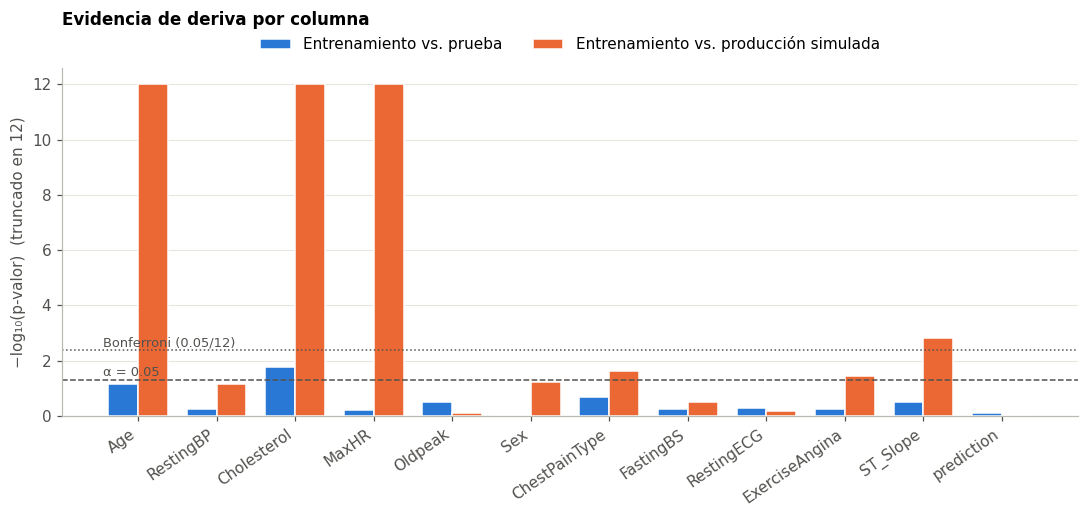

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.8))
x = np.arange(len(orden))
w = 0.38
for k, (escenario, color) in enumerate([("Entrenamiento vs. prueba", mu.COLORS["neg"]),
                                        ("Entrenamiento vs. producción simulada", mu.COLORS["pos"])]):
    d = detalle[detalle["Escenario"] == escenario].set_index("Columna").loc[orden]
    valores = np.clip(-np.log10(d["p-valor"].clip(lower=1e-12)), 0, 12)
    ax.bar(x + (k - 0.5) * w, valores, width=w, color=color, edgecolor="white", label=escenario)
ax.axhline(-np.log10(0.05), color=mu.COLORS["ink2"], ls="--", lw=1)
ax.text(-0.45, -np.log10(0.05) + 0.15, "α = 0.05", ha="left", fontsize=8.5, color=mu.COLORS["ink2"])
ax.axhline(-np.log10(bonferroni), color=mu.COLORS["ink2"], ls=":", lw=1)
ax.text(-0.45, -np.log10(bonferroni) + 0.15, "Bonferroni (0.05/12)", ha="left", fontsize=8.5,
        color=mu.COLORS["ink2"])
ax.set_xticks(x, orden, rotation=35, ha="right")
ax.set_ylabel("−log₁₀(p-valor)  (truncado en 12)")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.13))
ax.set_title("Evidencia de deriva por columna", pad=28)
fig.tight_layout()
mu.save_figure(fig, "fig10_deriva_pvalores")
plt.show()

**Figura 1.** Evidencia de deriva por columna, expresada como −log₁₀ del p-valor de la prueba que Evidently asigna a cada tipo de variable. Las barras que superan la línea discontinua corresponden a deriva detectada con α = 0.05; la línea punteada marca el umbral corregido por Bonferroni.

Entre entrenamiento y prueba, once de las doce columnas tienen p-valores entre 0.07 y 0.96, y solo `Cholesterol` cruza el umbral (p = 0.017). Ese resultado no indica un problema en la partición. Con doce pruebas a α = 0.05, la probabilidad de al menos una falsa alarma bajo la hipótesis nula es 1 − 0.95¹² ≈ 0.46, y con la corrección de Bonferroni (umbral 0.0042) ninguna columna resulta significativa. Además, la Figura 2 muestra el origen concreto de la diferencia: la partición aleatoria dejó un 23.4 % de colesteroles no reportados en prueba frente a un 17.6 % en entrenamiento, y la prueba de Kolmogorov-Smirnov es muy sensible a cambios en la masa puntual en cero. La regla de nivel de conjunto de Evidently, que exige deriva en al menos la mitad de las columnas, absorbe correctamente esta alarma aislada (1 de 12, 8.3 %).

En el lote simulado, las tres variables numéricas perturbadas presentan p-valores inferiores a 10⁻¹² y `ChestPainType` registra p = 0.024. La deriva también aparece en `ST_Slope` (p = 0.0015) y `ExerciseAngina` (p = 0.035), que no se modificaron. Su origen es metodológico: el lote se obtuvo remuestreando con reemplazo los 184 pacientes de prueba hasta 400, de modo que las pequeñas diferencias que la prueba ya tenía con el entrenamiento (p = 0.31 y 0.57) se replican con un tamaño muestral inflado por filas duplicadas, lo que viola el supuesto de independencia y aumenta artificialmente la potencia. Con seis columnas en deriva sobre doce, la proporción alcanza exactamente el umbral de 0.5 y el conjunto se declara con deriva.

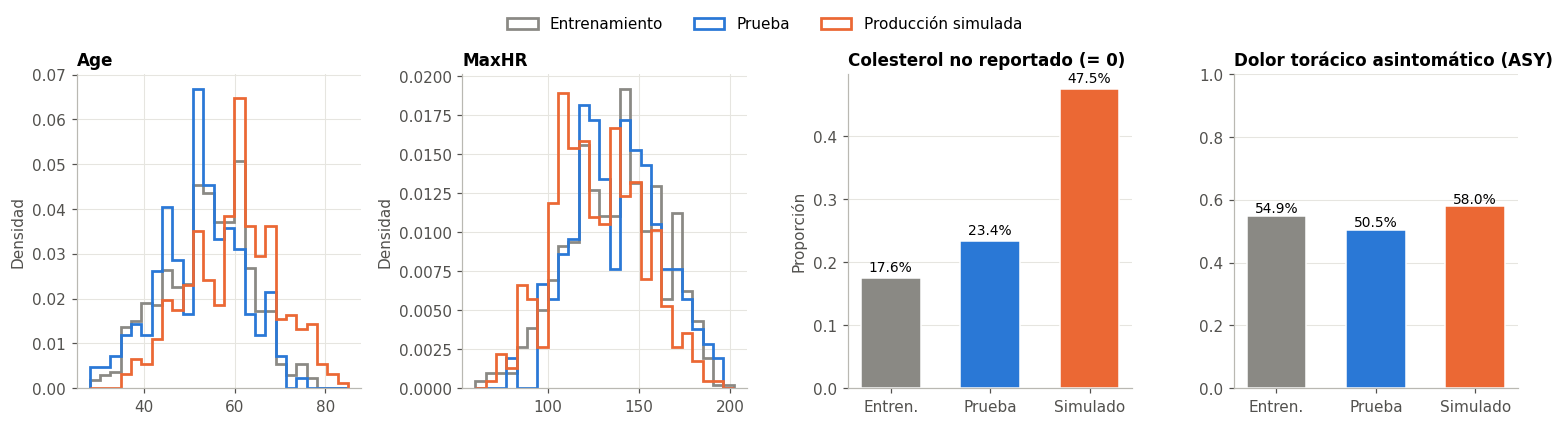

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
conjuntos = [("Entrenamiento", referencia, mu.COLORS["muted"]), ("Prueba", actual, mu.COLORS["neg"]),
             ("Producción simulada", simulado, mu.COLORS["pos"])]
for ax, var in zip(axes[:2], ["Age", "MaxHR"]):
    bins = np.histogram_bin_edges(pd.concat([c[var] for _, c, _ in conjuntos]), bins=25)
    for nombre, datos, color in conjuntos:
        ax.hist(datos[var], bins=bins, density=True, histtype="step", lw=1.8, color=color, label=nombre)
    ax.set_title(var)
    ax.set_ylabel("Densidad")
ax = axes[2]
props = [(d["Cholesterol"] == 0).mean() for _, d, _ in conjuntos]
ax.bar(range(3), props, color=[c for *_, c in conjuntos], width=0.6, edgecolor="white")
for i, v in enumerate(props):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)
ax.set_xticks(range(3), ["Entren.", "Prueba", "Simulado"])
ax.set_title("Colesterol no reportado (= 0)")
ax.set_ylabel("Proporción")
ax.grid(axis="x", visible=False)
ax = axes[3]
props = [(d["ChestPainType"] == "ASY").mean() for _, d, _ in conjuntos]
ax.bar(range(3), props, color=[c for *_, c in conjuntos], width=0.6, edgecolor="white")
for i, v in enumerate(props):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=9)
ax.set_xticks(range(3), ["Entren.", "Prueba", "Simulado"])
ax.set_title("Dolor torácico asintomático (ASY)")
ax.set_ylim(0, 1)
ax.grid(axis="x", visible=False)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
mu.save_figure(fig, "fig11_distribuciones_deriva")
plt.show()

**Figura 2.** Distribución de las cuatro variables perturbadas en la referencia, el conjunto de prueba y el lote de producción simulado.

Los desplazamientos de `Age` y `MaxHR` son evidentes a simple vista y explican los p-valores extremos. La proporción de colesterol no reportado se duplica (de 23.4 % en la base de prueba a 47.5 % en el lote), en línea con el mecanismo simulado. El cambio en `ChestPainType`, en cambio, es moderado (de 54.9 % a 58.0 % de pacientes asintomáticos respecto de la referencia) porque más de la mitad de los pacientes ya pertenecía a esa categoría y la reasignación del 30 % solo afecta a los demás, de ahí que su prueba chi-cuadrado responda con menos fuerza. El ejercicio muestra que la sensibilidad del monitoreo depende tanto de la magnitud de la perturbación como de la distribución de partida de cada variable.

## 4. Deriva de las entradas frente a deriva de las predicciones

In [6]:
tasas = pd.DataFrame({
    "Pacientes": [len(referencia), len(actual), len(simulado)],
    "Tasa de predicción positiva": [referencia["prediction"].mean(), actual["prediction"].mean(),
                                    simulado["prediction"].mean()],
    "Probabilidad media": [modelo.predict_proba(d[drift.FEATURES])[:, 1].mean()
                           for d in (referencia, actual, simulado)],
}, index=["Entrenamiento", "Prueba", "Producción simulada"])
tasas

,Pacientes,Tasa de predicción positiva,Probabilidad media
Entrenamiento,734,0.5708,0.5525
Prueba,184,0.5598,0.5379
Producción simulada,400,0.5725,0.5695


Pese a que la mitad de las columnas presenta deriva, la distribución de las predicciones permanece estable: la tasa de predicción positiva es de 0.571 en entrenamiento, 0.560 en prueba y 0.573 en el lote simulado, y la prueba Z sobre la columna `prediction` arroja p = 0.957. La probabilidad media sube apenas de 0.553 a 0.570. La explicación es coherente con la importancia por permutación de la Etapa 2: las variables más desplazadas, `Age` y `MaxHR`, tienen una contribución marginal casi nula al modelo (caídas de AUC de 0.003 y 0.002), mientras que la variable dominante, `ST_Slope`, no fue perturbada. El aumento de colesteroles no reportados, que sí influye en el modelo a través del indicador de ausencia, eleva la probabilidad media, pero el efecto no basta para mover la clase predicha de forma apreciable.

La consecuencia práctica es doble. Por un lado, la deriva de entradas no implica necesariamente deriva de salidas, y una alerta basada solo en la proporción de columnas desplazadas generaría falsas alarmas operativas. Por otro, la estabilidad de las predicciones tampoco garantiza que el desempeño se conserve: si en la población geriátrica la prevalencia real de enfermedad es mayor, como cabe esperar, un modelo que sigue prediciendo un 57 % de positivos estaría subestimando el riesgo. Esa deriva de concepto solo puede confirmarse cuando lleguen los desenlaces reales.

## 5. Lineamientos de monitoreo en producción

De los resultados anteriores se derivan los lineamientos de monitoreo propuestos para el servicio. Las solicitudes recibidas por la API deben registrarse y agruparse en ventanas de tamaño fijo, de al menos 200 pacientes únicos, para que las pruebas tengan potencia suficiente sin incurrir en la inflación por duplicados observada en la simulación; cada ventana se compara con el conjunto de referencia mediante `monitoring/drift_report.py`, que puede ejecutarse de forma programada (un `CronJob` en el clúster o el trabajo `drift` del workflow de CI).

La decisión de alertar no debería depender de un único p-valor. Se recomienda corregir por comparaciones múltiples, mantener la regla de proporción de columnas de Evidently como alerta de nivel de conjunto y ponderar las alertas individuales por la importancia de la variable en el modelo, de modo que un desplazamiento en `ST_Slope`, `ChestPainType`, `Sex` o `Cholesterol` reciba prioridad sobre uno en `RestingECG` o `MaxHR`. La proporción de colesteroles no reportados merece seguimiento propio, porque refleja cambios en los procesos de laboratorio que el modelo interpreta como señal clínica.

Finalmente, la deriva de las predicciones debe vigilarse sobre la distribución completa de probabilidades y no solo sobre la tasa de positivos. Cuando los desenlaces reales estén disponibles, se calcularán AUC, sensibilidad y especificidad por ventana; si el AUC cae por debajo de 0.90, el mismo umbral que exige la prueba automática del CI, o si la sensibilidad desciende de forma sostenida, el modelo debe reentrenarse con datos recientes y volver a pasar por el pipeline de validación de las Etapas 1 y 2.

## 6. Conclusiones

El monitoreo con `DataDriftPreset` de Evidently cumplió su propósito en los dos escenarios analizados. Entre entrenamiento y prueba no se detectó deriva del conjunto, y la única alarma individual (colesterol, p = 0.017) se explica por la variación muestral en la proporción de valores no reportados y desaparece al corregir por comparaciones múltiples. En el lote de producción simulado se detectó deriva en 6 de las 12 columnas, incluidas las cuatro perturbadas deliberadamente, lo que confirma la capacidad del procedimiento para identificar un cambio en la población atendida.

El análisis dejó dos lecciones que van más allá de la herramienta. La primera es que la deriva de las entradas no se tradujo en deriva de las predicciones, porque las variables desplazadas tienen poco peso en el modelo, de modo que las alertas deben interpretarse a la luz de la importancia de cada variable. La segunda es que el remuestreo con reemplazo y las comparaciones múltiples alteran la tasa de falsas alarmas, por lo que el diseño de las ventanas de monitoreo es tan importante como la prueba estadística elegida. Los reportes interactivos completos se encuentran en `drift_report.html` (entrenamiento frente a prueba) y en `reports/drift_report_simulated.html` (entrenamiento frente a producción simulada).

## 7. Referencias

- Evidently AI (2025). *Evidently documentation: Data drift preset* (versión 0.6). https://docs.evidentlyai.com
- Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M. y Bouchachia, A. (2014). A survey on concept drift adaptation. *ACM Computing Surveys*, 46(4), 1–37.
- Rabanser, S., Günnemann, S. y Lipton, Z. (2019). Failing loudly: An empirical study of methods for detecting dataset shift. *Advances in Neural Information Processing Systems*, 32.
- Rubio, L. (2023). *Machine Learning*, capítulo 10: Pipelines. https://lihkir.github.io/MachineLearning/chains_pipelines.html